# Initial EDA

Target Variable: ArrDelay

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
import s3fs
import polars as pl
import pandas as pd

In [2]:
fs = s3fs.S3FileSystem(
    key = os.environ["AWS_ACCESS_KEY_ID"],
    secret = os.environ["AWS_SECRET_ACCESS_KEY"],
    client_kwargs={"endpoint_url": os.environ["MLFLOW_S3_ENDPOINT_URL"]}
)

In [3]:
fs.ls("data-mining/data/joined_1704")

['data-mining/data/joined_1704/',
 'data-mining/data/joined_1704/test_data.parquet',
 'data-mining/data/joined_1704/train_data.parquet']

In [4]:
%%time
with fs.open("data-mining/data/joined_1704/train_data.parquet", "rb") as f:
    df = pd.read_parquet(f)


CPU times: user 8.86 s, sys: 9.81 s, total: 18.7 s
Wall time: 13.3 s


### Basic Shape and Schema

In [5]:
print(f"Shape: {df.shape}")

Shape: (13253650, 49)


In [6]:
df.dtypes

Year                                             int64
Month                                            int64
DayofMonth                                       int64
DayOfWeek                                        int64
FlightDate                                         str
Reporting_Airline                                  str
Tail_Number                                        str
Flight_Number_Reporting_Airline                  int64
Origin                                             str
Dest                                               str
CRSDepTime                                      object
DepTime                                         object
DepDelay                                       float64
DepDelayMinutes                                float64
TaxiOut                                        float64
WheelsOff                                       object
WheelsOn                                        object
TaxiIn                                         float64
CRSArrTime

In [20]:
df = df.sort_values(["Dest", "Timestamp"])

np.float64(4.769836549029741)

In [15]:
df.sample(5)[[
    "CRSArrTime", "ArrTime", "ArrDelay", "CRSDepTime", "DepTime", "DepDelay", "DepDelayMinutes", "Distance", "TZ_Origin", "Origin", "TZ_Dest", "Dest", "Timezone_Dest"
]]

,CRSArrTime,ArrTime,ArrDelay,CRSDepTime,DepTime,DepDelay,DepDelayMinutes,Distance,TZ_Origin,Origin,TZ_Dest,Dest,Timezone_Dest
6952820,23:59:00,23:51:00,-8.0,20:20:00,20:25:00,5.0,5.0,986.0,America/Chicago,DFW,America/New_York,DTW,-5
11264431,15:24:00,15:06:00,-18.0,12:48:00,12:42:00,-6.0,0.0,867.0,America/Los_Angeles,LAS,America/Los_Angeles,SEA,-8
1520058,12:30:00,12:27:00,-3.0,11:05:00,11:06:00,1.0,1.0,725.0,America/New_York,LGA,America/Chicago,MDW,-6
3412333,18:45:00,18:37:00,-8.0,17:00:00,16:54:00,-6.0,0.0,980.0,America/New_York,PHL,America/Chicago,MSP,-6
7692643,22:48:00,23:05:00,17.0,14:00:00,14:00:00,0.0,0.0,2586.0,America/Los_Angeles,SFO,America/New_York,JFK,-5


### Uniqueness / cardinality for categorical

In [8]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
df[cat_cols].nunique().sort_values(ascending=False).head(30)

/tmp/ipykernel_23486/3035567217.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns


Tail_Number          5579
FlightDate           2191
ArrTime              1440
WheelsOff            1440
WheelsOn             1440
CRSArrTime           1439
DepTime              1439
CRSDepTime           1273
Origin                 35
Dest                   35
Reporting_Airline       7
TZ_Origin               6
TZ_Dest                 6
dtype: int64

### Duplicates + key sanity checks

In [9]:
df.duplicated().mean()

np.float64(0.0)

In [10]:
df["ArrDelay"]

0           -16.0
1           -23.0
2            44.0
3           176.0
4           -18.0
            ...  
13253645     39.0
13253646     -4.0
13253647      8.0
13253648     27.0
13253649      4.0
Name: ArrDelay, Length: 13253650, dtype: float64

### 5. Target Distribution (ArrDelay)

In [11]:
target = 'ArrDelay'
if target not in df.columns:
    raise KeyError(f"Expected target column '{target}' not found.")

y = df[target]
print('Rows:', len(df))
print('ArrDelay missing rate:', float(y.isna().mean()))
print(y.describe(percentiles=[0.01, 0.05, 0.1, 0.5, 0.9, 0.95, 0.99]))

y_nonnull = y.dropna()
print('On-time or early (<=0):', float((y_nonnull <= 0).mean()))
print('Late >15 min:', float((y_nonnull > 15).mean()))
print('Very late >60 min:', float((y_nonnull > 60).mean()))

Rows: 13253650
ArrDelay missing rate: 0.014278557227631633
count    1.306441e+07
mean     4.769837e+00
std      4.128605e+01
min     -1.510000e+02
1%      -3.700000e+01
5%      -2.700000e+01
10%     -2.200000e+01
50%     -5.000000e+00
90%      3.700000e+01
95%      6.900000e+01
99%      1.720000e+02
max      2.444000e+03
Name: ArrDelay, dtype: float64
On-time or early (<=0): 0.6226893421186281
Late >15 min: 0.19207316489757248
Very late >60 min: 0.05920161550386482


In [12]:
df[["ArrDelay", "Tail_Number"]].sort_values(by="ArrDelay", ascending=False)

,ArrDelay,Tail_Number
3432027,2444.0,N549AA
10612330,2189.0,N863AA
7782217,2142.0,N878AA
8177365,2028.0,N870AA
7371569,1971.0,N3EAAA
...,...,...
13253042,NaN,N954WN
13253112,NaN,N8722L
13253201,NaN,N7849A
13253279,NaN,N935WN


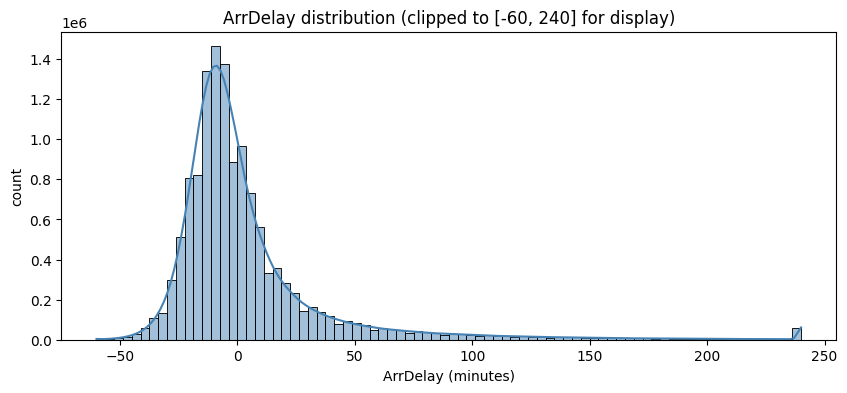

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Display-only clipping keeps plots readable without changing df.
y_clip = y_nonnull.clip(lower=-60, upper=240)

plt.figure(figsize=(10, 4))
sns.histplot(y_clip, bins=80, kde=True, color='steelblue')
plt.title('ArrDelay distribution (clipped to [-60, 240] for display)')
plt.xlabel('ArrDelay (minutes)')
plt.ylabel('count')
plt.show()

### 6. Time-Based Patterns (Seasonality + Time of Day)

In [14]:
# Most downstream EDA should ignore NaN ArrDelay (often cancelled/diverted flights).
d = df[df[target].notna()]

def delay_summary(g):
    s = g[target]
    return (
        g.size().rename('n')
        .to_frame()
        .assign(
            mean=s.mean(),
            median=s.median(),
            p90=s.quantile(0.90),
            late_gt15_rate=(s > 15).mean(),
        )
    )

by_month = delay_summary(d.groupby('Month'))
by_dow = delay_summary(d.groupby('DayOfWeek'))
display(by_month)
display(by_dow)

TypeError: '>' not supported between instances of 'SeriesGroupBy' and 'int'

In [ ]:
plt.figure(figsize=(10, 4))
sns.lineplot(x=by_month.index, y=by_month['median'], marker='o')
plt.title('Median ArrDelay by Month')
plt.xlabel('Month')
plt.ylabel('Median ArrDelay (min)')
plt.show()

# Hour-of-day from scheduled departure datetime (local schedule time)
if 'CRSDepDateTime' in d.columns:
    dep_hr = d['CRSDepDateTime'].dt.hour
    tmp = d.assign(SchedDepHour=dep_hr)
    by_hour = delay_summary(tmp.groupby('SchedDepHour'))
    plt.figure(figsize=(10, 4))
    sns.lineplot(x=by_hour.index, y=by_hour['median'], marker='o')
    plt.title('Median ArrDelay by Scheduled Departure Hour')
    plt.xlabel('Scheduled departure hour (0-23)')
    plt.ylabel('Median ArrDelay (min)')
    plt.show()
    display(by_hour)

### 7. Leakage Audit (Columns That Make ArrDelay Trivially Predictable)

In [ ]:
# These are often *post-flight* or *at-flight-time* variables.
# Useful for explaining what happened, but leaky if you want pre-departure prediction.
leaky_like = [
    'ArrTime', 'DepTime', 'WheelsOff', 'WheelsOn',
    'DepDelay', 'DepDelayMinutes', 'ArrDelayMinutes',
    'TaxiOut', 'TaxiIn', 'ActualElapsedTime', 'AirTime',
    'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay',
]
present = [c for c in leaky_like if c in df.columns]
print('Likely leakage columns present:', present)

# Quick numeric correlations with ArrDelay (very high values are a red flag)
num = d.select_dtypes(include='number')
cor = num.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
display(cor.head(25))

### 8. Segment Comparisons (Carrier / Airport / Route)

In [ ]:
def segment_summary(frame, col, top_n=15, min_n=5000):
    if col not in frame.columns:
        raise KeyError(f"Column '{col}' not found")

    g = frame.groupby(col)[target]
    out = pd.DataFrame({
        'n': g.size(),
        'mean': g.mean(),
        'median': g.median(),
        'p90': g.quantile(0.90),
        'late_gt15_rate': g.apply(lambda s: (s > 15).mean()),
    }).sort_values('n', ascending=False)

    out = out[out['n'] >= min_n]
    return out.head(top_n)

for col in ['Reporting_Airline', 'Origin', 'Dest']:
    if col in d.columns:
        print(f'\nTop {col} (min_n=5000):')
        display(segment_summary(d, col, top_n=15, min_n=5000))

In [ ]:
# Route comparisons
if {'Origin', 'Dest'}.issubset(d.columns):
    routes = d.assign(Route=d['Origin'].astype(str) + '-' + d['Dest'].astype(str))
    route_stats = segment_summary(routes, 'Route', top_n=20, min_n=5000)
    display(route_stats)

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=route_stats['n'], y=route_stats['median'])
    plt.title('Top Routes: Volume vs Median ArrDelay')
    plt.xlabel('n flights (log scale)')
    plt.ylabel('median ArrDelay (min)')
    plt.xscale('log')
    plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include='number').corr()

sns.heatmap(corr, cmap='coolwarm')
plt.show()